In [2]:
import pandas as pd
import glob
import os


def load_dataset(root_dir="LSNM2024/Dataset"):
    """Загрузить все CSV файлы из датасета"""
    benign_pattern = os.path.join(root_dir, "Benign", "*.csv")
    malicious_pattern = os.path.join(root_dir, "Malicious", "*", "*.csv")
    
    benign_files = glob.glob(benign_pattern)
    malicious_files = glob.glob(malicious_pattern)
    
    all_files = benign_files + malicious_files
    
    print(f"Найдено {len(all_files)} CSV файлов")
    print(f"  Benign: {len(benign_files)}")
    print(f"  Malicious: {len(malicious_files)}")
    
    return all_files


def extract_attack_class(filepath):
    """Извлечь класс атаки из пути файла (с учётом регистра и устойчиво к подстрокам)"""
    attack_classes = {
        'Benign': 'Benign',
        'ARP-spoof': 'ARP-spoof',
        'DDOS': 'DDoS',
        'DOS': 'DoS',
        'FTP': 'FTP-Attack',
        'Fuzzing': 'Fuzzing',
        'ICMP': 'ICMP-Flood',
        'Port': 'Port-Scanning',
        'RCE': 'RCE',
        'SQL': 'SQL-Injection',
        'SSH': 'SSH-Brute-Force',
        'syn': 'SYN-Flood',
        'XSS': 'XSS'
    }
    
    filepath_lower = filepath.lower()
    for key, value in attack_classes.items():
        if key.lower() in filepath_lower:
            return value
    return 'Unknown'


def load(all_files):
    """Загрузка всех CSV через pandas"""
    if not all_files:
        raise ValueError("Список файлов пуст. Нечего загружать.")

    dfs = []
    for file in all_files:
        try:
            # ПРОСТО pd.read_csv, БЕЗ assume_missing
            df = pd.read_csv(file)
            df["attack_type"] = "malicious" if "Malicious" in file else "benign"
            df["attack_class"] = extract_attack_class(file)
            dfs.append(df)
        except Exception as e:
            print(f"Ошибка при чтении файла {file}: {e}")
            continue

    if not dfs:
        raise ValueError("Не удалось загрузить ни один файл.")

    data = pd.concat(dfs, axis=0, ignore_index=True)

    # Для pandas никакого .compute и .npartitions нет
    n_rows, n_cols = data.shape
    print("\nЗагружено:")
    print(f"  Общее количество строк: {n_rows:,}")
    print(f"  Число признаков: {n_cols}")

    return data


if __name__ == "__main__":
    all_files = load_dataset()
    data = load(all_files)


Найдено 21 CSV файлов
  Benign: 1
  Malicious: 20


C:\Users\аля\AppData\Local\Temp\ipykernel_18016\3967433338.py:57: DtypeWarning: Columns (17,18,20,22,41,43,49,51,52,54,55,56,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\аля\AppData\Local\Temp\ipykernel_18016\3967433338.py:57: DtypeWarning: Columns (15,16,17,18,19,20,21,22,23,24,30,31,32,33,34,36,41,43,44,45,46,47,53,57,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\аля\AppData\Local\Temp\ipykernel_18016\3967433338.py:57: DtypeWarning: Columns (41,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\аля\AppData\Local\Temp\ipykernel_18016\3967433338.py:57: DtypeWarning: Columns (40,42,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
C:\Users\аля\AppData\Local\Temp\ipykernel_18016\3967433338.py:57: DtypeWarning: Columns (17,18,20,22,41


Загружено:
  Общее количество строк: 4,543,916
  Число признаков: 64


In [4]:
sample_frac = 0.1
data_sample = data.sample(frac=sample_frac, random_state=42)

print(len(data_sample), "строк в сэмпле")

454392 строк в сэмпле


In [3]:
target_col = "attack_class"

y = data_sample[target_col]
X = data_sample.drop(columns=[target_col])

In [4]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

In [5]:
numeric_cols

Index(['No.', 'Time', 'Length', 'frame number', 'frame length',
       'Frame Time (Epoch)', 'TCP Source Port', 'TCP Destination Port',
       'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number',
       'TCP Window Size', 'TCP Stream', 'UDP Source Port',
       'UDP Destination Port', 'UDP Length', 'ICMP Type', 'deltatime'],
      dtype='object')

In [6]:
categorical_cols

Index(['Source', 'Destination', 'Protocol', 'Info', 'Frame Time',
       'Frame Protocols', 'Ethernet Source', 'Ethernet Destination',
       'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL',
       'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version',
       'IP DSCP Field', 'IP Checksum', 'TCP Flags', 'TCP SYN Flag',
       'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Checksum',
       'UDP Checksum', 'ICMP Checksum', 'HTTP Request Method',
       'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI',
       'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length',
       'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer',
       'HTTP Location', 'HTTP Authorization', 'HTTP Connection',
       'DNS Query Name', 'DNS Query Type', 'label', 'attack_type'],
      dtype='object')

In [7]:
data_sample.isnull()

,No.,Time,Source,Destination,Protocol,Length,Info,frame number,frame length,Frame Time,...,HTTP Referer,HTTP Location,HTTP Authorization,HTTP Connection,DNS Query Name,DNS Query Type,label,attack_type,attack_class,deltatime
2742254,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,False,False,False
97524,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,False,True
2696383,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,False,True
2749750,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,False,False,False
917819,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2156488,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,False,False,True
2244667,False,False,False,False,False,False,False,True,False,False,...,True,True,True,True,True,True,True,False,False,True
2732496,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,False,False,False
3462541,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,False,False,True


In [8]:
import numpy as np

# Если data_sample получен через sample / фильтрацию — сначала делаем полноценную копию
data_sample = data_sample.copy()

# === 1. Числовые признаки ===

num_zero_fill = [
    "No.", "frame number",
    "TCP Sequence Number", "TCP Acknowledgment Number", "TCP Stream"
]
existing_zero = [c for c in num_zero_fill if c in data_sample.columns]
data_sample.loc[:, existing_zero] = data_sample[existing_zero].fillna(0)

num_median_fill = [col for col in numeric_cols if col not in num_zero_fill and col in data_sample.columns]
medians = data_sample[num_median_fill].median()
data_sample.loc[:, num_median_fill] = data_sample[num_median_fill].fillna(medians)

# === 2. Удаляем строки с пропусками в целевых метках ===
data_sample = data_sample.dropna(subset=["label", "attack_type"]).copy()

# === 3. TCP-флаги: бинарные признаки, отсутствие = "0" ===
flag_cols = ["TCP SYN Flag", "TCP ACK Flag", "TCP FIN Flag", "TCP RST Flag"]
for col in flag_cols:
    if col in data_sample.columns:
        data_sample.loc[:, col] = data_sample[col].fillna("0")

# === 4. Протоколы — заменяем на "Unknown" ===
proto_cols = ["Protocol", "Frame Protocols", "IP Protocol"]
for col in proto_cols:
    if col in data_sample.columns:
        data_sample.loc[:, col] = data_sample[col].fillna("Unknown")

# === 5. Адреса и имена ===
addr_cols = [
    "Source", "Destination",
    "Ethernet Source", "Ethernet Destination",
    "IP Source", "IP Destination",
    "DNS Query Name", "HTTP Host"
]
for col in addr_cols:
    if col in data_sample.columns:
        data_sample.loc[:, col] = data_sample[col].fillna("Unknown")

# === 6. HTTP-поля — "NA" ===
http_cols = [col for col in categorical_cols if col.startswith("HTTP ") and col in data_sample.columns]
for col in http_cols:
    data_sample.loc[:, col] = data_sample[col].fillna("NA")

# === 7. Остальные категориальные — мода ===
remaining_cat_cols = [
    col for col in categorical_cols
    if col not in ["label", "attack_type"] + http_cols + addr_cols + proto_cols + flag_cols
]

for col in remaining_cat_cols:
    if col not in data_sample.columns:
        continue
    mode_val = data_sample[col].mode(dropna=True)
    fill_value = mode_val.iloc[0] if not mode_val.empty else "Unknown"
    data_sample.loc[:, col] = data_sample[col].fillna(fill_value)


In [9]:
print("Осталось пропусков:")
print(data_sample.isna().sum().sum())

Осталось пропусков:
0


In [10]:
data_sample.head(5)

,No.,Time,Source,Destination,Protocol,Length,Info,frame number,frame length,Frame Time,...,HTTP Referer,HTTP Location,HTTP Authorization,HTTP Connection,DNS Query Name,DNS Query Type,label,attack_type,attack_class,deltatime
97524,97525,6453.884218,192.168.1.109,192.168.1.108,TCP,2962,80 > 38738 [ACK] Seq=201007 Ack=178 Win=6912...,97525.0,2962,"Dec 7, 2023 16:28:31.548089489 +03",...,NA,NA,NA,NA,Unknown,A (Host Address),normal,benign,Benign,0.000211
2696383,126079,33.388400,192.168.1.109,192.168.1.108,TCP,60,"48577 > 50233 [RST, ACK] Seq=1 Ack=1 Win=0 L...",126079.0,60,"Nov 14, 2023 18:05:53.586715142 +03",...,NA,NA,NA,NA,Unknown,A (Host Address),Exploiting-FTP,malicious,FTP-Attack,0.000211
917819,84367,20.592619,192.168.1.108,192.168.1.104,TCP,66,39346 > 80 [ACK] Seq=1 Ack=1 Win=64256 Len=0...,84367.0,66,"Feb 26, 2024 15:58:22.654865000 +03",...,NA,NA,NA,NA,Unknown,A (Host Address),normal,benign,Benign,0.000211
350573,14166,2.439959,192.168.1.108,192.168.1.104,TCP,74,48374 > 80 [SYN] Seq=0 Win=64240 Len=0 MSS=1...,14166.0,74,"Feb 26, 2024 15:11:13.975358000 +03",...,NA,NA,NA,NA,Unknown,A (Host Address),normal,benign,Benign,0.000211
1229810,198641,35.403398,192.168.1.108,192.168.1.104,TCP,66,"58716 > 80 [FIN, ACK] Seq=102 Ack=2782 Win=6...",198641.0,66,"Feb 26, 2024 16:00:10.561606000 +03",...,NA,NA,NA,NA,Unknown,A (Host Address),normal,benign,Benign,0.000211


In [11]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd
import numpy as np

# Убедимся, что работаем с копией
df_enc = data_sample.copy()

# Списки признаков
low_cardinality = [
    'Protocol', 'IP Protocol', 'HTTP Response Code', 'TCP Flags',
    'IP Flags', 'Ethernet Type', 'ICMP Type'
]

high_cardinality = [
    'Source', 'Destination', 'IP Source', 'IP Destination',
    'HTTP Host', 'DNS Query Name', 'HTTP User-Agent', 'HTTP Content Type'
]

flag_cols = ['TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag']

# Убираем из категориальных то, что уже обработаем отдельно
other_cat_cols = [
    col for col in categorical_cols
    if col not in low_cardinality + high_cardinality + flag_cols + ['label', 'attack_type']
]


In [12]:
print("Типы в low_cardinality:")
for col in low_cardinality:
    if col in df_enc.columns:
        print(f"{col}: {df_enc[col].dtype} | NaN: {df_enc[col].isna().sum()}")
        print(f"  Уникальные типы: {df_enc[col].apply(type).unique()}")

Типы в low_cardinality:
Protocol: object | NaN: 0
  Уникальные типы: [<class 'str'>]
IP Protocol: object | NaN: 0
  Уникальные типы: [<class 'str'>]
HTTP Response Code: object | NaN: 0
  Уникальные типы: [<class 'str'> <class 'float'>]
TCP Flags: object | NaN: 0
  Уникальные типы: [<class 'str'>]
IP Flags: object | NaN: 0
  Уникальные типы: [<class 'str'>]
Ethernet Type: object | NaN: 0
  Уникальные типы: [<class 'str'>]
ICMP Type: float64 | NaN: 0
  Уникальные типы: [<class 'float'>]


In [13]:
 #явно обработать проблемные колонки
problem_cols = ['HTTP Response Code', 'ICMP Type']

for col in low_cardinality:
    if col in df_enc.columns:
        # Если float → str, иначе оставляем как есть
        if df_enc[col].dtype.kind in 'fc':
            df_enc[col] = df_enc[col].astype(str)
        elif df_enc[col].dtype == 'object':
            # Для object уже проверили типы — оставляем
            pass

df_enc['HTTP Response Code'] = df_enc['HTTP Response Code'].astype(str)
# Теперь проверка должна показать только lass 'str'>
print("После исправления:")
for col in low_cardinality:
    print(f"{col}: {df_enc[col].dtype} | типы: {df_enc[col].apply(type).unique()}")

После исправления:
Protocol: object | типы: [<class 'str'>]
IP Protocol: object | типы: [<class 'str'>]
HTTP Response Code: object | типы: [<class 'str'>]
TCP Flags: object | типы: [<class 'str'>]
IP Flags: object | типы: [<class 'str'>]
Ethernet Type: object | типы: [<class 'str'>]
ICMP Type: object | типы: [<class 'str'>]


In [14]:
# 1. TCP флаги (только если есть)
for col in flag_cols:
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].map({'0': 0, '1': 1}).fillna(0).astype(int)

# 2. OHE только для реально существующих low_cardinality
existing_low_card = [col for col in low_cardinality if col in df_enc.columns]
if existing_low_card:
    print(f"OHE для: {existing_low_card}")
    encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    low_card_data = df_enc[existing_low_card].astype(str).copy()
    low_card_encoded = pd.DataFrame(
        encoder.fit_transform(low_card_data),
        columns=encoder.get_feature_names_out(),
        index=df_enc.index
    )
    df_enc = df_enc.drop(columns=existing_low_card)
    df_enc = pd.concat([df_enc, low_card_encoded], axis=1)
    print(f"✅ OHE завершено: {low_card_encoded.shape}")
else:
    print("⏭️  OHE пропущен (нет колонок)")

# 3. Frequency Encoding (тоже с проверкой)
for col in high_cardinality:
    if col in df_enc.columns:
        freq_map = df_enc[col].value_counts().to_dict()
        df_enc[f'{col}_freq'] = df_enc[col].map(freq_map).fillna(0)

# 4. LabelEncoder для остальных (тоже безопасно)
for col in other_cat_cols:
    if col in df_enc.columns:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# 5. Last Protocol (НАДЕЖНО)
try:
    if 'Frame Protocols' in df_enc.columns:
        # Принудительно к строкам + обработка
        protocols = df_enc['Frame Protocols'].astype(str)
        df_enc['Last Protocol'] = protocols.str.split(':').str[-1].fillna('other')
        
        last_proto_dummies = pd.get_dummies(df_enc['Last Protocol'], prefix='LastProto', dummy_na=True)
        df_enc = pd.concat([df_enc, last_proto_dummies], axis=1)
        df_enc.drop(columns=['Frame Protocols', 'Last Protocol'], inplace=True, errors='ignore')
        print("✅ Last Protocol feature добавлен")
except Exception as e:
    print(f"⏭️ Last Protocol пропущен: {e}")

print(f"✅ Финальный размер: {df_enc.shape}")


OHE для: ['Protocol', 'IP Protocol', 'HTTP Response Code', 'TCP Flags', 'IP Flags', 'Ethernet Type', 'ICMP Type']
✅ OHE завершено: (160882, 51)
✅ Last Protocol feature добавлен
✅ Финальный размер: (160882, 165)


In [15]:
df_enc.head(5)

,No.,Time,Source,Destination,Length,Info,frame number,frame length,Frame Time,Frame Time (Epoch),...,LastProto_45,LastProto_46,LastProto_47,LastProto_48,LastProto_5,LastProto_6,LastProto_7,LastProto_8,LastProto_9,LastProto_nan
97524,97525,6453.884218,192.168.1.109,192.168.1.108,2962,70483,97525.0,2962,19417,1.701956e+09,...,False,False,False,False,False,False,False,False,False,False
2696383,126079,33.388400,192.168.1.109,192.168.1.108,60,32230,126079.0,60,136011,1.699974e+09,...,False,False,False,False,False,False,False,False,False,False
917819,84367,20.592619,192.168.1.108,192.168.1.104,66,17532,84367.0,66,92743,1.708952e+09,...,False,False,False,False,False,False,False,False,False,False
350573,14166,2.439959,192.168.1.108,192.168.1.104,74,31951,14166.0,74,44671,1.708949e+09,...,False,False,False,False,False,False,False,False,False,False
1229810,198641,35.403398,192.168.1.108,192.168.1.104,66,54263,198641.0,66,120575,1.708952e+09,...,False,False,False,False,False,False,False,False,False,False


In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Шаг 1: Подготовка данных для моделирования
# Используем уже обработанные данные из df_enc
print("Подготовка данных для моделирования...")

# Определим признаки и целевую переменную
feature_columns = [col for col in df_enc.columns if col not in ['attack_type', 'attack_class', 'label']]
X = df_enc[feature_columns]
y = data_sample['attack_class']  # используем оригинальный столбец из data_sample

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Классы: {y.unique()}")

Подготовка данных для моделирования...
Размер X: (160882, 162)
Размер y: (160882,)
Классы: ['Benign' 'FTP-Attack' 'ARP-spoof' 'Fuzzing']


In [21]:
# Шаг 2: Кодирование целевой переменной
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Классы: {label_encoder.classes_}")
print(f"Количество классов: {len(label_encoder.classes_)}")
print(f"Распределение классов:")
for i, class_name in enumerate(label_encoder.classes_):
    count = sum(y_encoded == i)
    print(f"  {class_name}: {count}")

Классы: ['ARP-spoof' 'Benign' 'FTP-Attack' 'Fuzzing']
Количество классов: 4
Распределение классов:
  ARP-spoof: 9632
  Benign: 125632
  FTP-Attack: 13703
  Fuzzing: 11915


In [22]:
# Шаг 3: Разделение данных на тренировочную, валидационную и тестовую выборки
from sklearn.model_selection import train_test_split

# Сначала отделим тестовую часть
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Затем разделим оставшуюся часть на тренировочную и валидационную
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2 от общего объема
)

print(f"Размеры выборок:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Размеры выборок:
X_train: (96528, 162), y_train: (96528,)
X_val: (32177, 162), y_val: (32177,)
X_test: (32177, 162), y_test: (32177,)


In [23]:
# Шаг 4: Проверка распределения классов в выборках
import numpy as np

print("Распределение классов в тренировочной выборке:")
unique, counts = np.unique(y_train, return_counts=True)
for i, count in enumerate(counts):
    class_name = label_encoder.classes_[unique[i]]
    print(f"  {class_name}: {count}")

print("\nРаспределение классов в валидационной выборке:")
unique, counts = np.unique(y_val, return_counts=True)
for i, count in enumerate(counts):
    class_name = label_encoder.classes_[unique[i]]
    print(f"  {class_name}: {count}")

print("\nРаспределение классов в тестовой выборке:")
unique, counts = np.unique(y_test, return_counts=True)
for i, count in enumerate(counts):
    class_name = label_encoder.classes_[unique[i]]
    print(f"  {class_name}: {count}")

Распределение классов в тренировочной выборке:
  ARP-spoof: 5780
  Benign: 75378
  FTP-Attack: 8221
  Fuzzing: 7149

Распределение классов в валидационной выборке:
  ARP-spoof: 1926
  Benign: 25127
  FTP-Attack: 2741
  Fuzzing: 2383

Распределение классов в тестовой выборке:
  ARP-spoof: 1926
  Benign: 25127
  FTP-Attack: 2741
  Fuzzing: 2383


In [27]:
# Шаг 5: Обработка признаков - заполнение пропусков и масштабирование
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Разделим признаки на числовые и категориальные
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Числовые признаки: {len(numeric_features)}")
print(f"Категориальные признаки: {len(categorical_features)}")

# Заполним пропуски в числовых признаках медианой
if numeric_features:
    numeric_imputer = SimpleImputer(strategy='median')
    X_train_numeric = numeric_imputer.fit_transform(X_train[numeric_features])
    X_val_numeric = numeric_imputer.transform(X_val[numeric_features])
    X_test_numeric = numeric_imputer.transform(X_test[numeric_features])
    
    # Преобразуем обратно в DataFrame
    X_train_numeric = pd.DataFrame(X_train_numeric, columns=numeric_features, index=X_train.index)
    X_val_numeric = pd.DataFrame(X_val_numeric, columns=numeric_features, index=X_val.index)
    X_test_numeric = pd.DataFrame(X_test_numeric, columns=numeric_features, index=X_test.index)

# Заполним пропуски в категориальных признаках модой (наиболее частым значением)
if categorical_features:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    X_train_categorical = categorical_imputer.fit_transform(X_train[categorical_features])
    X_val_categorical = categorical_imputer.transform(X_val[categorical_features])
    X_test_categorical = categorical_imputer.transform(X_test[categorical_features])
    
    # Преобразуем обратно в DataFrame
    X_train_categorical = pd.DataFrame(X_train_categorical, columns=categorical_features, index=X_train.index)
    X_val_categorical = pd.DataFrame(X_val_categorical, columns=categorical_features, index=X_val.index)
    X_test_categorical = pd.DataFrame(X_test_categorical, columns=categorical_features, index=X_test.index)

# Объединим числовые и категориальные признаки
if numeric_features and categorical_features:
    X_train_imputed = pd.concat([X_train_numeric, X_train_categorical], axis=1)
    X_val_imputed = pd.concat([X_val_numeric, X_val_categorical], axis=1)
    X_test_imputed = pd.concat([X_test_numeric, X_test_categorical], axis=1)
elif numeric_features:
    X_train_imputed = X_train_numeric
    X_val_imputed = X_val_numeric
    X_test_imputed = X_test_numeric
else:
    X_train_imputed = X_train_categorical
    X_val_imputed = X_val_categorical
    X_test_imputed = X_test_categorical

print("Пропуски после заполнения:")
print(f"X_train: {X_train_imputed.isnull().sum().sum()}")
print(f"X_val: {X_val_imputed.isnull().sum().sum()}")
print(f"X_test: {X_test_imputed.isnull().sum().sum()}")

Числовые признаки: 104
Категориальные признаки: 58
Пропуски после заполнения:
X_train: 0
X_val: 0
X_test: 0


In [29]:
# Шаг 6: Отбор признаков с помощью статистических методов
from sklearn.feature_selection import SelectKBest, f_classif

# Выберем только числовые признаки для отбора (так как f_classif работает только с числовыми данными)
X_train_numeric_only = X_train_imputed.select_dtypes(include=[np.number])
X_val_numeric_only = X_val_imputed.select_dtypes(include=[np.number])
X_test_numeric_only = X_test_imputed.select_dtypes(include=[np.number])

print(f"Числовые признаки для отбора: {X_train_numeric_only.shape[1]}")

# Выберем 100 лучших признаков по ANOVA F-test
k_features = min(100, X_train_numeric_only.shape[1])
selector = SelectKBest(score_func=f_classif, k=k_features)
X_train_selected = selector.fit_transform(X_train_numeric_only, y_train)
X_val_selected = selector.transform(X_val_numeric_only)
X_test_selected = selector.transform(X_test_numeric_only)

# Получим названия выбранных признаков
selected_features = X_train_numeric_only.columns[selector.get_support()]
print(f"Выбрано {len(selected_features)} признаков:")
print(list(selected_features))

# Преобразуем обратно в DataFrame
X_train_final = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train_numeric_only.index)
X_val_final = pd.DataFrame(X_val_selected, columns=selected_features, index=X_val_numeric_only.index)
X_test_final = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test_numeric_only.index)

print(f"Финальные размеры:")
print(f"X_train: {X_train_final.shape}")
print(f"X_val: {X_val_final.shape}")
print(f"X_test: {X_test_final.shape}")

Числовые признаки для отбора: 104
Выбрано 100 признаков:
['No.', 'Time', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Ethernet Source', 'Ethernet Destination', 'IP Length', 'IP TTL', 'IP Fragment Offset', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Content-Length', 'HTTP Cookie', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Type', 'deltatime', 'Protocol_ARP', 'Protocol_BROWSER', 'Protocol_DHCP', 'Protocol_DNS', 'Protocol_EXEC', 'Protocol_FTP', 'Protocol_HTTP', 'Protocol_HTTP/XML', 'Protocol_ICMP', 'Protocol_ICMPv6', 'Protocol_IRC', 'Protocol_MySQL', 'Protocol_NBNS', 'Prot

In [30]:
# Шаг 7: Обучение модели LightGBM с учетом категориальных признаков
import lightgbm as lgb

# Определим параметры модели
params = {
    'objective': 'multiclass',
    'num_class': len(label_encoder.classes_),
    'boosting_type': 'gbdt',
    'num_leaves': 50,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 10,
    'min_data_in_leaf': 50,
    'is_unbalance': True,
    'metric': ['multi_logloss', 'multi_error'],
    'verbosity': -1,
    'random_state': 42
}

# Создадим датасеты для LightGBM
train_data = lgb.Dataset(X_train_final, label=y_train)
val_data = lgb.Dataset(X_val_final, label=y_val, reference=train_data)

print("Начинаем обучение модели...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

Начинаем обучение модели...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	training's multi_logloss: 0.0277253	training's multi_error: 0	valid_1's multi_logloss: 0.0277539	valid_1's multi_error: 0


In [31]:
# Шаг 8: Предсказания на тестовой выборке
import numpy as np

# Получим предсказания
y_pred_proba = model.predict(X_test_final)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Предсказания выполнены")
print(f"Форма предсказаний: {y_pred.shape}")
print(f"Форма вероятностей: {y_pred_proba.shape}")

Предсказания выполнены
Форма предсказаний: (32177,)
Форма вероятностей: (32177, 4)


In [32]:
# Шаг 9: Оценка качества модели
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Вычислим метрики
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Точность (Accuracy): {accuracy:.4f}")
print(f"F1-мера (macro): {f1_macro:.4f}")
print(f"F1-мера (weighted): {f1_weighted:.4f}")

print("\nКлассификационный отчет:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Точность (Accuracy): 1.0000
F1-мера (macro): 1.0000
F1-мера (weighted): 1.0000

Классификационный отчет:
              precision    recall  f1-score   support

   ARP-spoof       1.00      1.00      1.00      1926
      Benign       1.00      1.00      1.00     25127
  FTP-Attack       1.00      1.00      1.00      2741
     Fuzzing       1.00      1.00      1.00      2383

    accuracy                           1.00     32177
   macro avg       1.00      1.00      1.00     32177
weighted avg       1.00      1.00      1.00     32177



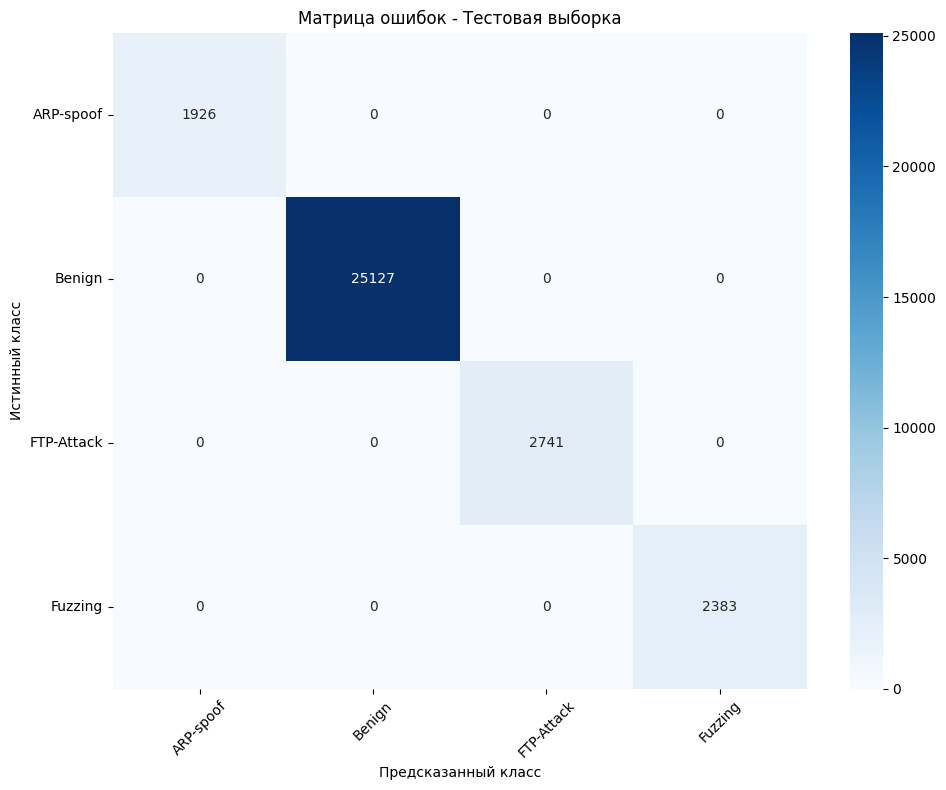

In [33]:
# Шаг 10: Визуализация матрицы ошибок
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок - Тестовая выборка')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

нарисовать график - выбрать ошибки еще раз первого и второго рода
вкладки с архитектурой модели (загрузка датасетов)
